In [1]:
import sys
sys.path.append('../')

import numpy as np
import scipy.sparse as ssp
import matplotlib.pyplot as plt
import qutip as qt
import scqubits as scq
from matplotlib.colors import LogNorm
from tqdm import tqdm
from qutip.qip.operations import rz, cz_gate
import cmath
from sympy import symbols
import utils_2Q_gate_zp as ut
ut.set_fig_font() ### Set various sizes in plotting
import scipy as sp
from joblib import Parallel, delayed
import itertools
from qutip.qip.operations import rz, cz_gate, cnot, rx, hadamard_transform, swap
from scipy.ndimage import gaussian_filter
import pandas as pd

### Get fidelity for input params

In [ ]:
truc1, truc_tot, charge_pick = 300, 1000, False
truc_full = 1000

folder = f'../../data/3ncut_two_zeropi/truc1={truc1}_truc2={truc_tot}_pick={charge_pick}/'
eval_tot = 2*np.pi* pd.read_csv(folder+ 'eval_tot.txt').to_numpy().flatten()
n_theta0_dress = 2*np.pi* np.load(folder+'n_theta0_dress.npy')
n_theta1_dress = 2*np.pi* np.load(folder+'n_theta1_dress.npy')
hspace_full = pd.read_csv(folder+ 'hspace_full.txt').to_numpy().flatten().tolist()

truc_list = np.arange(truc_full)
hspace_full = hspace_full[:truc_full]
eval_tot = eval_tot[:truc_full]
n_theta0_dress = ut.truncate_2(n_theta0_dress, truc_list)
n_theta1_dress = ut.truncate_2(n_theta1_dress, truc_list)

workers, popsize = 100, 10
recombination, tol, mutation = [0.7, 0.01, (0.5, 1.0)]

logi_state = ['0-0', '0-2', '2-0', '2-2']
idx_0 = hspace_full.index('0-2')
idx_1 = hspace_full.index('2-2')
idx_2 = hspace_full.index('8-2')
W_0_2 = eval_tot[idx_2] - eval_tot[idx_0]
W_1_2 = eval_tot[idx_2] - eval_tot[idx_1]

H0_full = qt.Qobj(np.diag(eval_tot))
logi_idx_full = [hspace_full.index(i) for i in logi_state]
state_full = [qt.basis(truc_full, i) for i in range(truc_full)]
H_drive_full = [ H0_full,   [n_theta0_dress, ut.drive_gauss_A],
                            [n_theta0_dress, ut.drive_gauss_B]  ]

c_op_list = []
num_cpus = 16
[tg, drive_amp_A, drive_amp_B, detune_A, detune_B] =[200.001513, 0.029121, 0.018721, -0.005572, -0.005265]
arg_optimize = [tg, drive_amp_A, drive_amp_B, detune_A, detune_B]
pulse_args = {'drive_amp_A': drive_amp_A ,
            'drive_freq_A': W_0_2 + 2*np.pi*detune_A,
            'drive_amp_B': drive_amp_B ,
            'drive_freq_B': W_1_2 + 2*np.pi*detune_B,
            'gate_time': tg }
tlist = np.linspace(0, tg, num=int(tg))  # total time
logi_state_one = [0,2]

In [16]:
# Population in select
result = {}
for idx, state_i in enumerate(logi_state_one):
    for jdx, state_j in tqdm(enumerate(logi_state_one)):
        # This simulation is just for viewing the affect of the pulse
        result[idx, jdx] = qt.mesolve(
            H_drive_full,
            qt.basis(truc_full, hspace_full.index( str(state_i) +'-'+str(state_j) )),
            tlist,
            e_ops=[state * state.dag() for state in state_full],
            args=pulse_args,
            options=qt.Options(store_states=True, nsteps=1e4, num_cpus=16) )

2it [04:45, 142.69s/it]
2it [04:42, 141.18s/it]


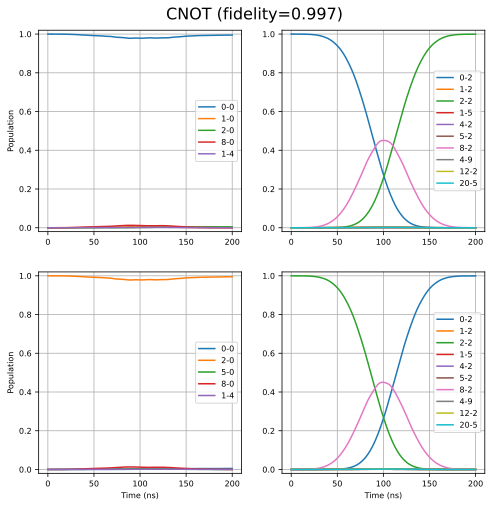

In [22]:
fig, ax = plt.subplots(figsize=(8,8), nrows=2, ncols=2)
fig.suptitle(f"CNOT (fidelity=0.997)", fontsize=16, y=0.92)
for idx, state_i in enumerate(logi_state_one):
    for jdx, state_j in enumerate(logi_state_one):
        for kdx, res in zip(hspace_full, result[idx,jdx].expect):
            y_pop = gaussian_filter( np.array(res).flatten(), 3)
            if np.max(y_pop) > 0.001:
                ax[idx][jdx].plot(tlist, gaussian_filter( np.array(res).flatten(), 3) ,  label=r"%s" %kdx)
        ax[idx][jdx].set_ylim(-0.02,1.02)
        ax[idx][jdx].grid()
        ax[idx][jdx].legend()
    ax[1][idx].set_xlabel('Time (ns)')
    ax[idx][0].set_ylabel('Population')
    # handles, labels = ax[idx][jdx].get_legend_handles_labels()
    # fig.legend(handles,labels, ncol=10,
    #     loc='upper center', bbox_to_anchor=(0.5, 0.05)).get_frame().set_alpha(0.1)

In [13]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

In [ ]:
# Fidelity in select
hspace_select = [
'0-0', '0-1', '1-0', '0-2', '2-0', '0-4', '4-0', '1-1', '0-5', '2-1' ,
'5-0', '1-2', '0-8', '2-2', '8-0', '1-4', '4-1', '2-4', '9-0', '1-5' ,
'5-1', '4-2', '0-12', '2-5', '1-8', '12-0', '5-2', '8-1', '4-4', '13-0' ,
'15-0', '2-8', '1-9', '9-1', '8-2', '5-4', '4-5', '0-18', '2-9', '0-21' ,
'18-0', '9-2', '12-1', '5-5', '0-24', '4-8', '1-13', '20-0', '8-4', '22-0' ,
'2-12', '13-1', '24-0', '0-25', '15-1', '5-8', '4-9', '12-2', '9-4', '8-5' ,
'25-0', '13-2', '26-0', '1-18', '15-2', '5-9', '4-12', '0-30', '18-1', '12-4' ,
'9-5', '1-21', '8-8', '20-1', '4-13', '22-1', '4-16', '30-0', '13-4', '5-12' ,
'15-4', '24-1', '33-0', '18-2', '34-0', '2-21', '8-9', '35-0', '1-25', '9-8' ,
'12-5', '37-0', '20-2', '5-16', '22-2', '13-5', '25-1', '26-1', '24-2', '15-5' ,
'2-25', '39-0', '8-12', '2-26', '9-9', '18-4', '28-1', '12-8', '41-0', '0-45' ,
'4-21', '13-8', '25-2', '20-4', '22-4', '4-24', '26-2', '5-18', '15-8', '30-1' ,
'9-12', '44-0', '12-9', '28-2', '45-0', '33-1', '18-5', '2-30', '46-0', '34-1' ,
'13-9', '9-13', '9-16', '20-5', '22-5', '50-0', '30-2', '25-4', '15-9', '8-18' ,
'24-5', '12-12', '33-2', '18-8', '34-2', '35-2', '13-12', '41-1', '37-2', '22-8' ,
'56-0', '25-5', '26-5', '30-4', '18-9', '39-2', '13-16', '59-0', '33-4', '28-5' ,
'41-2', '35-4', '20-9', '22-9', '25-8', '65-0', '26-8', '24-9', '30-5', '12-18' ,
'44-2', '33-5', '45-2', '34-5', '35-5', '46-2', '12-20', '69-0', '37-5', '26-9' ,
'50-2', '51-2', '39-5', '54-2', '41-5', '56-2', '58-2', '34-9', '18-20', '59-2' ,
'44-5', '45-5', '60-2', '41-8', '46-5', '64-2', '65-2', '33-12', '50-5', '51-5' ,
]
index_select = [hspace_full.index(i) for i in hspace_select]
H0_select = ut.truncate_2( H0_full, index_select)
len_select = len(hspace_select)
n_theta0_select = ut.truncate_2(n_theta0_dress, index_select)
logi_idx_select = [hspace_select.index(i) for i in logi_state]
state_select = [qt.basis(len_select, i) for i in range(len_select)]
H_drive_select = [ H0_select,   [n_theta0_select, ut.drive_gauss_A],
                                [n_theta0_select, ut.drive_gauss_B]  ]

arg_select = [H_drive_select, W_0_2, W_1_2, num_cpus, c_op_list, logi_idx_select]
f_select = ut.cnot_fidelity_log_tg(arg_optimize, *arg_select)
print(f' f_full (dim={len_select}) = ', f_select)
print('fidelity real = ', 1-10**f_select)


# Population in select
result = {}
for idx, state_i in enumerate(logi_state_one):
    for jdx, state_j in tqdm(enumerate(logi_state_one)):
        # This simulation is just for viewing the affect of the pulse
        result[idx, jdx] = qt.mesolve(
            H_drive_select,
            qt.basis(len_select, hspace_select.index( str(state_i) +'-'+str(state_j) )),
            tlist,
            e_ops=[state * state.dag() for state in state_select],
            args=pulse_args,
            options=qt.Options(store_states=True, nsteps=1e4)  )

fig, ax = plt.subplots(figsize=(8,8), nrows=2, ncols=2)
order = ['(a)', '(b)','(c)','(d)']
for idx, state_i in enumerate(logi_state_one):
    for jdx, state_j in enumerate(logi_state_one):
        for kdx, res in zip(hspace_select, result[idx,jdx].expect):
            y_pop = gaussian_filter( np.array(res).flatten(), 3)
            # if np.max(y_pop) > 0.001:
            ax[idx][jdx].plot(tlist, gaussian_filter( np.array(res).flatten(), 3) ,  label=r"%s" %kdx)
        ax[idx][jdx].set_ylim(-0.02,1.02)
        ax[idx][jdx].grid()
        # ax[idx][jdx].legend()
    ax[1][idx].set_xlabel('Time (ns)')
    ax[idx][0].set_ylabel('Population')

    handles, labels = ax[idx][jdx].get_legend_handles_labels()
    fig.legend(handles,labels, ncol=5,
        loc='upper center', bbox_to_anchor=(0.5, 0.05)).get_frame().set_alpha(0.1)

 f_full (dim=200) =  -0.7118681015876595
fidelity real =  0.8058524571641797


In [94]:
# # Fidelity in full
# arg_full = [H_drive_full, W_0_2, W_1_2, num_cpus, c_op_list, logi_idx_full]
# f_full = ut.cnot_fidelity_log_tg(arg_optimize, *arg_full)
# print(f' f_full (dim={truc_full}) = ', f_full)

# # Population in full
# result = {}
# for idx, state_i in enumerate(logi_state_one):
#     for jdx, state_j in tqdm(enumerate(logi_state_one)):
#         # This simulation is just for viewing the affect of the pulse
#         result[idx, jdx] = qt.mesolve(
#             H_drive_full,
#             qt.basis(truc_full, hspace_full.index( str(state_i) +'-'+str(state_j) )),
#             tlist,
#             e_ops=[state * state.dag() for state in state_full],
#             args=pulse_args,
#             options=qt.Options(store_states=True, nsteps=1e4)  )